# Báo Cáo EDA Phân Tích Dữ Liệu Phụ Tùng Ô Tô (HBAAC 2026)

Notebook này chứa các bước Khám phá và Phân tích Dữ liệu (EDA). Mục tiêu là cung cấp các bằng chứng thống kê (statistical evidence) để hỗ trợ các quyết định trong quá trình Feature Engineering, đồng thời nhận diện các rủi ro về Data Leakage và Time Series Continuity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

## 1. Kiểm Tra Giá Trị Khuyết Thiếu (Missing Values)
Đánh giá trạng thái khuyết thiếu trên snapshot dữ liệu hiện tại.

In [2]:
df = pd.read_csv('train.csv', low_memory=False)
missing_stats = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Pct': (df.isnull().sum() / len(df)) * 100
})
print(missing_stats)

             Missing_Count  Missing_Pct
Date                     0          0.0
Stt                      0          0.0
ItemCode                 0          0.0
Quantity                 0          0.0
UnitPrice                0          0.0
SalesAmount              0          0.0
Unit Cost                0          0.0
Cost Amount              0          0.0


**Nhận định:**
Không quan sát thấy giá trị khuyết thiếu (NaN) trong snapshot dữ liệu huấn luyện hiện tại. Tuy nhiên, điều này chưa đủ căn cứ để loại trừ hoàn toàn các cơ chế missingness (MCAR/MAR/MNAR) khi hệ thống vận hành thực tế ở môi trường Production. Tạm thời không áp dụng các chiến lược Imputation, nhưng pipeline cần có cơ chế fallback nếu inference sinh ra NaN.

## 2. Tiền Xử Lý Dữ Liệu & Phân Tích Đuôi Nặng (Heavy-Tail Analysis)
Sử dụng QQ-Plot để cung cấp bằng chứng trực quan về phân phối lệch và kiểm tra đuôi dữ liệu trước khi quyết định Winsorize.

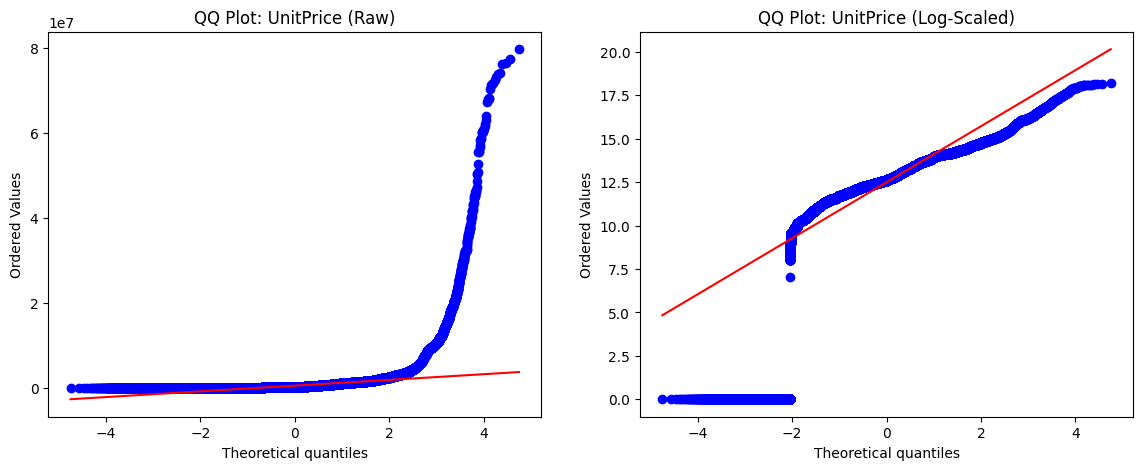

In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df['Cost Amount'] = df['Cost Amount'].astype(str).str.replace(',', '.').astype(float)
df['UnitPrice'] = df['UnitPrice'].astype(str).str.replace(',', '.').astype(float)
df['Unit Cost'] = df['Unit Cost'].astype(str).str.replace(',', '.').astype(float)
df['SalesAmount'] = df['SalesAmount'].astype(float)

returns_df = df[df['Quantity'] < 0].copy()
sales_df = df[df['Quantity'] >= 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
stats.probplot(sales_df['UnitPrice'], dist="norm", plot=axes[0])
axes[0].set_title('QQ Plot: UnitPrice (Raw)')
stats.probplot(np.log1p(sales_df['UnitPrice']), dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot: UnitPrice (Log-Scaled)')
plt.show()

price_threshold = sales_df['UnitPrice'].abs().quantile(0.999)
quantity_threshold = sales_df['Quantity'].quantile(0.999)
cleaned_sales = sales_df[(sales_df['UnitPrice'].abs() <= price_threshold) & (sales_df['Quantity'] <= quantity_threshold)].copy()
cleaned_sales['Gross_Margin'] = cleaned_sales['SalesAmount'] - cleaned_sales['Cost Amount']

**Nhận định:**
Biểu đồ QQ-Plot (bên trái) lệch xa khỏi đường phân phối chuẩn, cung cấp bằng chứng rõ ràng về hiện tượng heavy-tail. Phép biến đổi Log (bên phải) cải thiện đáng kể cấu trúc dữ liệu nhưng vẫn còn nhiễu ở hai đầu mút.
Quyết định áp dụng ngưỡng quantile(0.999) cần được theo dõi cẩn trọng (Temporal Leakage Risk): Trong pipeline thực tế, ngưỡng này chỉ được fit trên tập Train (tránh rò rỉ dữ liệu từ tập Validation).

## 3. Phân Đoạn Sản Phẩm ABC (Pareto)
Khảo sát cấu trúc danh mục sản phẩm. Những mô hình Tree-based (như LightGBM) có tính chống chịu (robust) tốt hơn với phân phối lệch, nhưng extreme imbalance ở Target vẫn có thể gây chệch split density. Việc phân nhóm ABC giúp kiểm soát rủi ro này.

In [4]:
sku_margin = cleaned_sales.groupby('ItemCode')['Gross_Margin'].sum().sort_values(ascending=False).reset_index()
sku_margin['Cum_Pct'] = sku_margin['Gross_Margin'].cumsum() / sku_margin['Gross_Margin'].sum()

def assign_abc(pct):
    if pct <= 0.80: return 'A'
    elif pct <= 0.95: return 'B'
    else: return 'C'

sku_margin['ABC_Class'] = sku_margin['Cum_Pct'].apply(assign_abc)
print(sku_margin['ABC_Class'].value_counts(normalize=True) * 100)

ABC_Class
C    73.847412
B    16.617397
A     9.535191
Name: proportion, dtype: float64


## 4. Time Series Continuity & Kiểm Định Chu Kỳ (ACF/PACF)
Việc kiểm tra ACF trên chuỗi Aggregate tổng thể dễ dẫn đến Simpson's Paradox (trộn lẫn chu kỳ ngày, tuần, tháng của các SKU khác biệt). Dưới đây, ta lấy mẫu (sample) Top SKUs thuộc nhóm A và tái cấu trúc lưới thời gian (Full Calendar Grid) để đảm bảo continuity trước khi tính toán ACF và Lag.

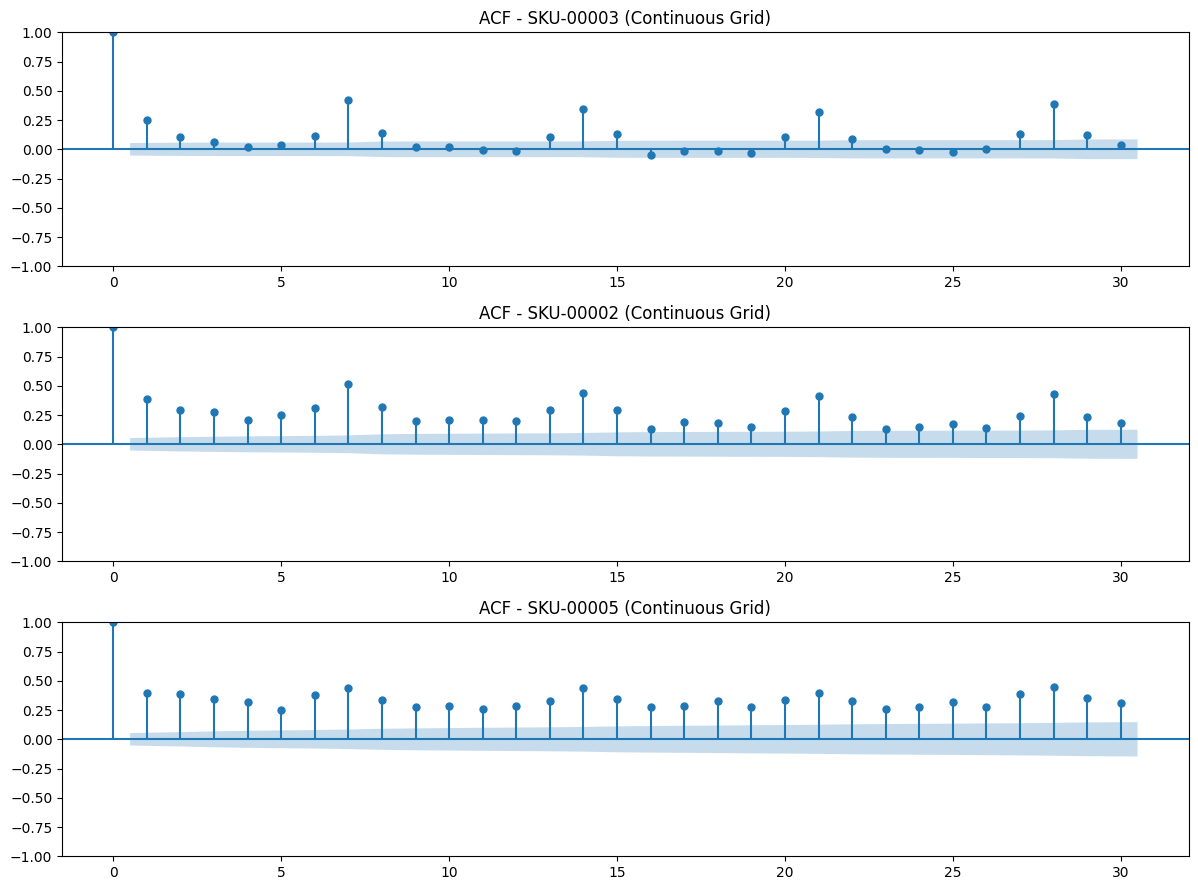

In [5]:
top_skus = sku_margin.head(3)['ItemCode'].tolist()
sample_sales = cleaned_sales[cleaned_sales['ItemCode'].isin(top_skus)]
daily_sample = sample_sales.groupby(['Date', 'ItemCode'])['Quantity'].sum().reset_index()

date_range = pd.date_range(start=daily_sample['Date'].min(), end=daily_sample['Date'].max())
grid = pd.MultiIndex.from_product([date_range, top_skus], names=['Date', 'ItemCode']).to_frame(index=False)
continuous_ts = pd.merge(grid, daily_sample, on=['Date', 'ItemCode'], how='left').fillna(0)
continuous_ts.sort_values(['ItemCode', 'Date'], inplace=True)

fig, axes = plt.subplots(len(top_skus), 1, figsize=(12, 3 * len(top_skus)))
for i, sku in enumerate(top_skus):
    sku_series = continuous_ts[continuous_ts['ItemCode'] == sku]['Quantity']
    plot_acf(sku_series, lags=30, ax=axes[i], title=f'ACF - {sku} (Continuous Grid)')
plt.tight_layout()
plt.show()

**Nhận định:**
Bằng việc sử dụng lưới thời gian liên tục, ta đảm bảo các bước dịch chuyển (shift) sau này phản ánh chính xác khoảng cách số ngày vật lý. Tín hiệu ACF trên các Top SKU riêng biệt cho thấy các dạng thức mùa vụ khác nhau, ủng hộ việc xây dựng Lag Features dựa trên Calendar Grid thay vì chuỗi log giao dịch thô.

## 5. Đánh Giá Tính Dừng (Stationarity) Cấp Độ Danh Mục
Thực hiện kiểm định ADF trên aggregate series để lấy cái nhìn tổng quan. Khuyến nghị kiểm tra stationarity ở cấp độ cụm (cluster) trong giai đoạn Modeling tiếp theo.

In [6]:
agg_series = cleaned_sales.groupby('Date')['Quantity'].sum().dropna()
adf_res = adfuller(agg_series)
kpss_res = kpss(agg_series)
print(f"ADF p-value: {adf_res[1]:.4f}")
print(f"KPSS p-value: {kpss_res[1]:.4f}")

ADF p-value: 0.1657
KPSS p-value: 0.0100


**Nhận định:**
Kết quả ADF reject giả thuyết Null (H0) cho thấy chuỗi tổng có dấu hiệu dừng (không có unit root mạnh). Tuy nhiên, điều này không đồng nghĩa với việc chuỗi miễn nhiễm với các structural breaks, regime shift hoặc heteroskedasticity. Cần thận trọng đánh giá lại các seasonal shock (Lễ Tết) trước khi kết luận hoàn toàn không cần kỹ thuật differencing.

## 6. Phân Tích Tính Ổn Định & Biến Động Kênh Phân Phối (Demand Volatility)
Thử nghiệm đo lường Hệ số biến thiên bình phương (CV²) và Average Demand Interval (ADI) để phân loại tính chất chuỗi (Smooth, Intermittent, Erratic, Lumpy) cho Top SKUs.

In [7]:
adi_cv2_stats = []
for sku in top_skus:
    s = continuous_ts[continuous_ts['ItemCode'] == sku]['Quantity']
    non_zero = s[s > 0]
    if len(non_zero) > 0:
        adi = len(s) / len(non_zero)
        cv2 = (non_zero.std() / non_zero.mean())**2
    else:
        adi, cv2 = np.nan, np.nan
    adi_cv2_stats.append({'SKU': sku, 'ADI': adi, 'CV2': cv2})

volatility_df = pd.DataFrame(adi_cv2_stats)
print(volatility_df)

         SKU       ADI       CV2
0  SKU-00003  1.266038  0.437935
1  SKU-00002  1.512965  0.559358
2  SKU-00005  4.167702  1.005771


**Nhận định cuối:**
Phân tích ADI/CV² chứng minh rằng ngay cả trong Top A SKUs, vẫn có rủi ro intermittency (nhu cầu ngắt quãng). Các biến Lag cần đi kèm với Rolling Statistics (như Rolling Mean/Std) để hỗ trợ mô hình Machine Learning nắm bắt tốt hơn các biên độ dao động này.